# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.



In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('loan_data.csv')

# Display first few rows of the dataset
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


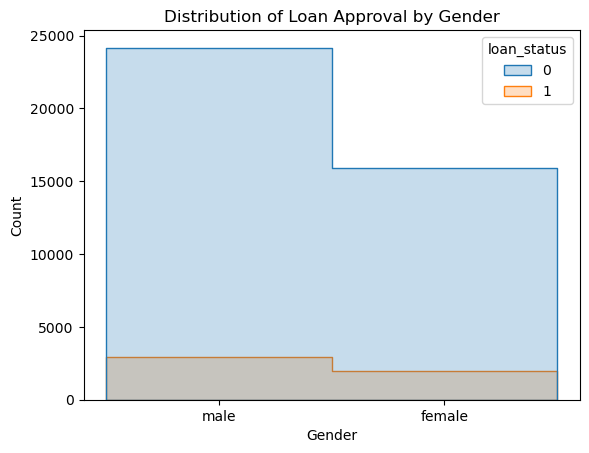

In [4]:
sns.histplot(x='person_gender', element="step", hue="loan_status", data=df)

plt.title('Distribution of Loan Approval by Gender')
plt.xlabel('Gender')
plt.show()

In [5]:
pd.crosstab(df['person_gender'], df['loan_status'], normalize='index')

loan_status,0,1
person_gender,,
female,0.889720,0.110280
male,0.892289,0.107711


Initially it seems like the approval for Males and Females is equal. Lets start seperating the genders with other qualifying elements.

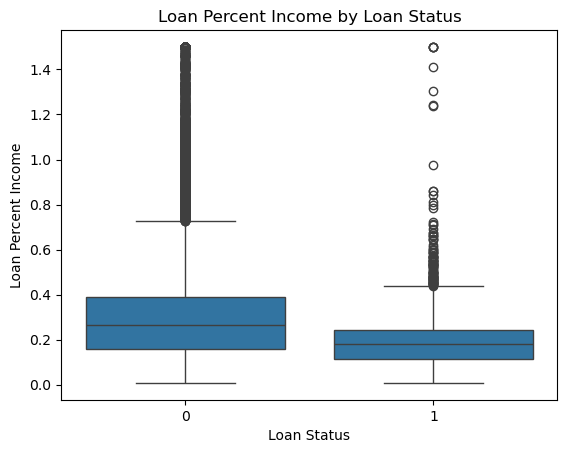

In [7]:
sns.boxplot(x='loan_status', y='loan_percent_income', data=df)
plt.title('Loan Percent Income by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Loan Percent Income')
plt.show()

I kept having crashes trying to get this boxplot. Apparently it doesn't like to have the loan_status in the y-coordinates. I'll have to stick with this I guess.

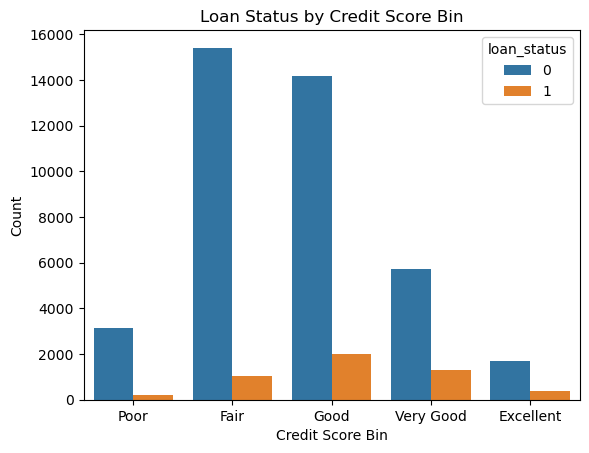

In [9]:
credit_score_bin = pd.cut(df['credit_score'], bins=[300, 579, 669, 739, 799, 850], labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'])
df['credit_score_bin'] = credit_score_bin
sns.countplot(x='credit_score_bin', hue='loan_status', data=df)
plt.title('Loan Status by Credit Score Bin')
plt.xlabel('Credit Score Bin')
plt.ylabel('Count')
plt.show()

/var/folders/mv/t13jdm3s54s17c3skn916gcw0000gn/T/ipykernel_65233/3231934881.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approved = df.groupby(['credit_score_bin', 'person_gender'])['loan_status'].mean().reset_index(name='approval_rate')


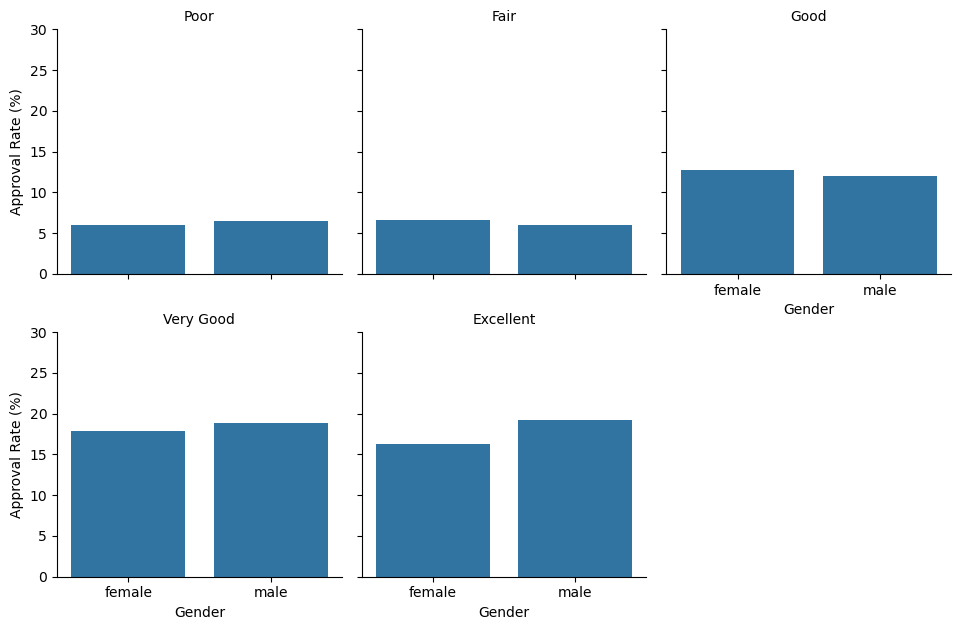

In [14]:
# compute approval rate (proportion approved) per (credit_score_bin, person_gender)
approved = df.groupby(['credit_score_bin', 'person_gender'])['loan_status'].mean().reset_index(name='approval_rate')
approved['approval_rate_pct'] = approved['approval_rate'] * 100

# bar plot of approval percentage by gender, faceted by credit score bin
g = sns.catplot(
    data=approved,
    x='person_gender',
    y='approval_rate_pct',
    col='credit_score_bin',
    col_wrap=3,
    kind='bar',
    height=3.2,
    sharey=True
)
g.set_axis_labels('Gender', 'Approval Rate (%)')
g.set_titles(col_template='{col_name}')
for ax in g.axes.flatten():
    ax.set_ylim(0, 30)
plt.tight_layout()
plt.show()

/var/folders/mv/t13jdm3s54s17c3skn916gcw0000gn/T/ipykernel_65233/2310153025.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rejected = df.groupby(['credit_score_bin', 'person_gender'])['loan_status'].apply(lambda x: (x == 0).sum() / len(x)).reset_index(name='rejection_rate')


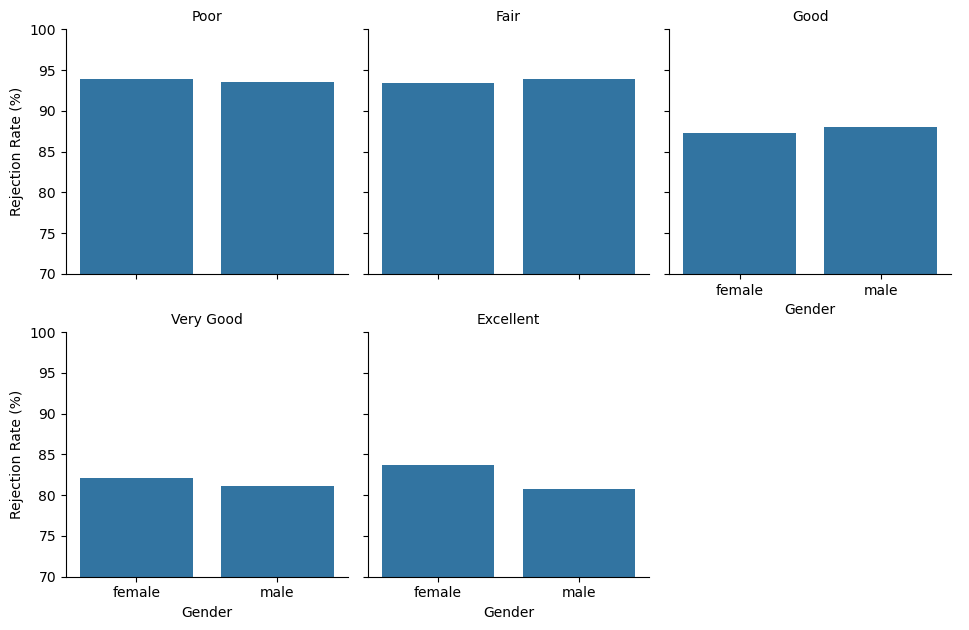

In [15]:
# compute approval rate (proportion rejected) per (credit_score_bin, person_gender)
rejected = df.groupby(['credit_score_bin', 'person_gender'])['loan_status'].apply(lambda x: (x == 0).sum() / len(x)).reset_index(name='rejection_rate')
rejected['rejection_rate_pct'] = rejected['rejection_rate'] * 100

# bar plot of rejection percentage by gender, faceted by credit score bin
g_rejected = sns.catplot(
    data=rejected,
    x='person_gender',
    y='rejection_rate_pct',
    col='credit_score_bin',
    col_wrap=3,
    kind='bar',
    height=3.2,
    sharey=True
)
g_rejected.set_axis_labels('Gender', 'Rejection Rate (%)')
g_rejected.set_titles(col_template='{col_name}')
for ax in g_rejected.axes.flatten():
    ax.set_ylim(70, 100)
plt.tight_layout()
plt.show()

It looks as if Rejection Rates and Approval Rates are also fairly equal. There does seem to be a slightly higher rejection rate for Women with Very-Good to Excellent credit score. Males with a Good credit score tend to be rejected slightly more.

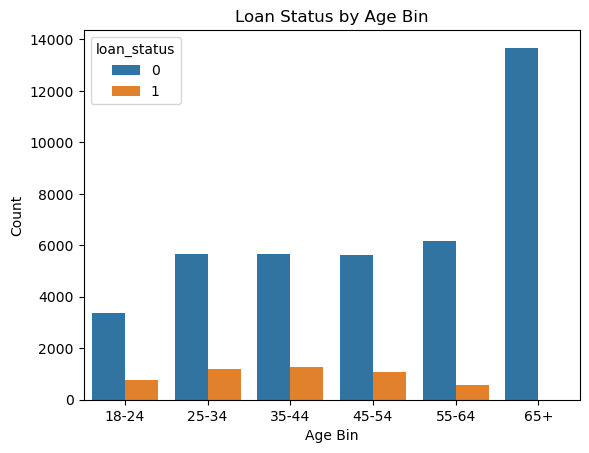

In [16]:
age_bins = pd.cut(df['person_age'], bins=[18, 25, 35, 45, 55, 65, 100], labels=['18-24', '25-34', '35-44', '45-54', '55-64', '65+'])
df['age_bin'] = age_bins
sns.countplot(x='age_bin', hue='loan_status', data=df)
plt.title('Loan Status by Age Bin')
plt.xlabel('Age Bin')
plt.ylabel('Count')
plt.show()

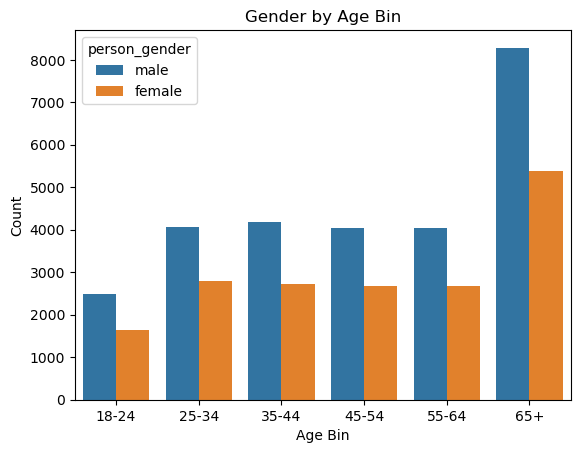

In [17]:
sns.countplot(x='age_bin', hue='person_gender', data=df)
plt.title('Gender by Age Bin')
plt.xlabel('Age Bin')
plt.ylabel('Count')
plt.show()

Here it clearly shows that Senior Citizens has a much higher rejection rate. Now personally, I don't think this is unfair. From a banking point-of-view, mortality-rates need to be considered for loan repayment. If a "Average Lifespan of an American" was weighed-in (which it is in reality) it would disqualify many people who would pass-away before their loan was repayed. I wouldn't be concerned with any legal trouble with this finding. But lets look into loan amounts to see how "unrealistic" it would be for a senior to payback a loan that got rejected.

/var/folders/mv/t13jdm3s54s17c3skn916gcw0000gn/T/ipykernel_65233/3608463933.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approval = df_old.groupby('age_bin')['loan_status'].mean().reindex(bins).reset_index()
/var/folders/mv/t13jdm3s54s17c3skn916gcw0000gn/T/ipykernel_65233/3608463933.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_bin', y='approval_pct', data=approval, order=bins, ax=axes[1], palette='Blues_d')


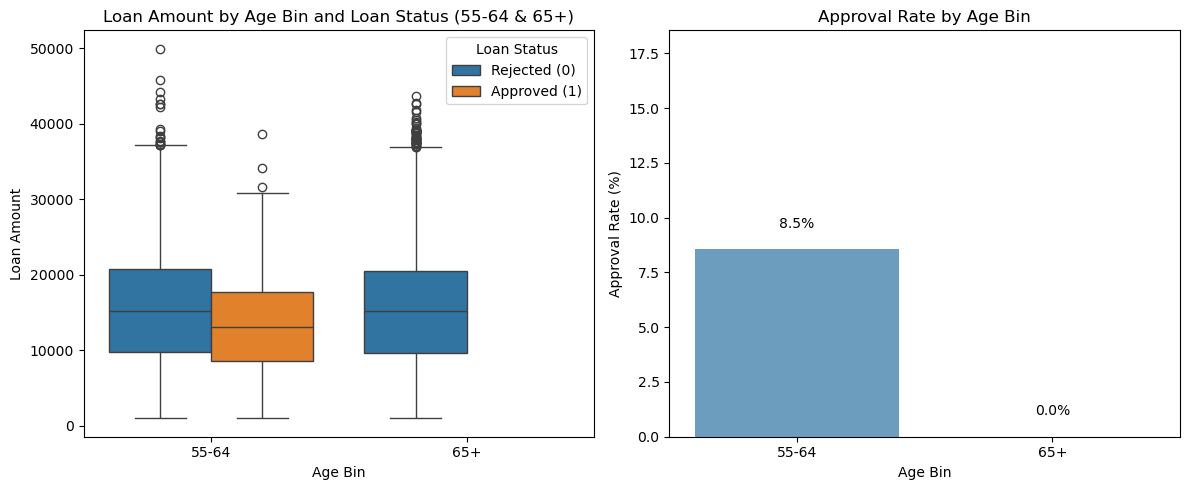

In [20]:
# filter for the two age bins
bins = ['55-64', '65+']
df_old = df[df['age_bin'].isin(bins)].copy()

# compute approval rates for each bin (limit to the two bins and preserve order)
approval = df_old.groupby('age_bin')['loan_status'].mean().reindex(bins).reset_index()
approval.columns = ['age_bin', 'approval_rate']
approval['approval_pct'] = approval['approval_rate'] * 100
approval['approval_pct'] = approval['approval_pct'].fillna(0)

# plot: left = loan amount distribution by age bin & status, right = approval rates
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# boxplot of loan amounts by age_bin, split by loan_status (only 55-64 and 65+)
sns.boxplot(x='age_bin', y='loan_amnt', hue='loan_status', data=df_old, order=bins, ax=axes[0])
axes[0].set_title('Loan Amount by Age Bin and Loan Status (55-64 & 65+)')
axes[0].set_xlabel('Age Bin')
axes[0].set_ylabel('Loan Amount')
handles, _ = axes[0].get_legend_handles_labels()
axes[0].legend(handles, ['Rejected (0)', 'Approved (1)'], title='Loan Status')

# barplot of approval percentage (only the two bins)
sns.barplot(x='age_bin', y='approval_pct', data=approval, order=bins, ax=axes[1], palette='Blues_d')
axes[1].set_ylim(0, min(100, approval['approval_pct'].max() + 10))
axes[1].set_title('Approval Rate by Age Bin')
axes[1].set_ylabel('Approval Rate (%)')
axes[1].set_xlabel('Age Bin')

# annotate bars with percentages
for i, (_, row) in enumerate(approval.iterrows()):
    if pd.isna(row['approval_pct']):
        txt = "N/A"
        y = 0
    else:
        txt = f"{row['approval_pct']:.1f}%"
        y = row['approval_pct']
    axes[1].text(i, y + 1, txt, ha='center')

plt.tight_layout()
plt.show()

Separating the approval a rejection rate by age-bins for the over 55 age-group, we can see that even in the "younger" of the two groups, loan approvals were a majority of lower-value loans. The 65+ age group were almost entirely applying for "larger" loans, which would be a sort of double-whammy for rejection. No legal trouble here.

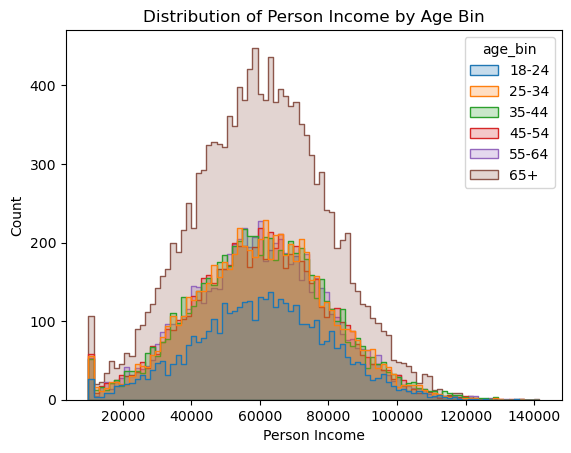

In [22]:
sns.histplot(x='person_income', element="step", hue="age_bin", data=df) 
plt.title('Distribution of Person Income by Age Bin')
plt.xlabel('Person Income')
plt.show()

So thsi definately raises some eyebrows. Individual 65+ have a very similar anual income as all other age-groups. I think the big differentiator in this metric would be home-ownership, or more generally, Debt-to-income. Since DTI is not in the data set, lets use home-ownership.

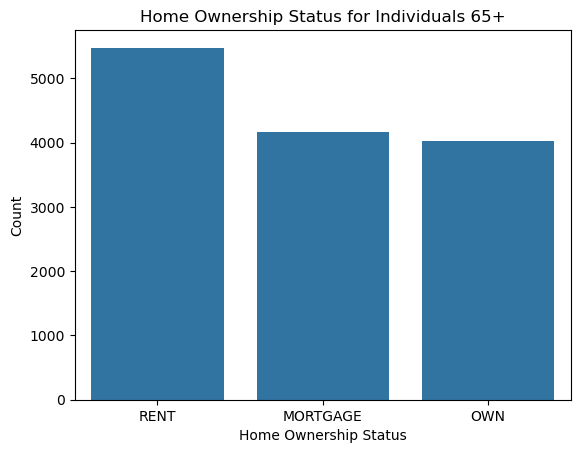

In [23]:
# Filter for individuals aged 65+
df_65plus = df[df['age_bin'] == '65+']

# Plot home ownership status distribution for 65+ age group
sns.countplot(x='person_home_ownership', data=df_65plus, order=df_65plus['person_home_ownership'].value_counts().index)
plt.title('Home Ownership Status for Individuals 65+')
plt.xlabel('Home Ownership Status')
plt.ylabel('Count')
plt.show()

Here we can see that less than 1/3 of the 65+ applicants actually own their home. This leaves that age-group, generally, in a dangerous place for increasing housing costs due to property-taxes, acts of god, insurance-claims ect... One could possibly argue that, of the individuals 65+ who OWN their home outright, should have at least some level of approval.

I would confortably say that this institution should have to cause for legal concern. Although all things can be improved upon, I don't think that there is any blatant descrimination.